## Task 2-Experimentation and Uplift testing

Julia has asked us to evaluate the performance of a store trial which was performed in stores 77, 86 and 88.

This can be broken down by:

1. Total sales revenue
2. Total number of customers
3. Average number of transactions per customer

Create a measure to compare different control stores to each of the trial stores to do this write a function to reduce having to re-do the analysis for each trial store. Consider using Pearson correlations or a metric such as a magnitude distance e.g. 1- (Observed distance – minimum distance)/(Maximum distance – minimum distance) as a measure.

Once you have selected your control stores, compare each trial and control pair during the trial period. You want to test if total sales are significantly different in the trial period and if so, check if the driver of change is more purchasing customers or more purchases per customers etc.

Main areas of Focus are :

1. Select control stores – Explore data, define metrics, visualize graphs
2. Assessment of the trial – insights/trends by comparing trial stores with control stores
3. Collate findings – summarize and provide recommendations

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
import numpy as np
     

In [2]:
df = pd.read_csv(r"C:\Users\karan\Desktop\Projectt\Quantium\QVI_data.csv")
df.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [3]:
df.isnull().sum()

LYLTY_CARD_NBR      0
DATE                0
STORE_NBR           0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
BRAND               0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [4]:
df.describe()

,LYLTY_CARD_NBR,STORE_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES,PACK_SIZE
count,2.648340e+05,264834.000000,2.648340e+05,264834.000000,264834.000000,264834.000000,264834.000000
mean,1.355488e+05,135.079423,1.351576e+05,56.583554,1.905813,7.299346,182.425512
std,8.057990e+04,76.784063,7.813292e+04,32.826444,0.343436,2.527241,64.325148
min,1.000000e+03,1.000000,1.000000e+00,1.000000,1.000000,1.500000,70.000000
25%,7.002100e+04,70.000000,6.760050e+04,28.000000,2.000000,5.400000,150.000000
50%,1.303570e+05,130.000000,1.351365e+05,56.000000,2.000000,7.400000,170.000000
75%,2.030940e+05,203.000000,2.026998e+05,85.000000,2.000000,9.200000,175.000000
max,2.373711e+06,272.000000,2.415841e+06,114.000000,5.000000,29.500000,380.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   LYLTY_CARD_NBR    264834 non-null  int64  
 1   DATE              264834 non-null  object 
 2   STORE_NBR         264834 non-null  int64  
 3   TXN_ID            264834 non-null  int64  
 4   PROD_NBR          264834 non-null  int64  
 5   PROD_NAME         264834 non-null  object 
 6   PROD_QTY          264834 non-null  int64  
 7   TOT_SALES         264834 non-null  float64
 8   PACK_SIZE         264834 non-null  int64  
 9   BRAND             264834 non-null  object 
 10  LIFESTAGE         264834 non-null  object 
 11  PREMIUM_CUSTOMER  264834 non-null  object 
dtypes: float64(1), int64(6), object(5)
memory usage: 24.2+ MB


In [24]:
df['DATE'] = pd.to_datetime(df['DATE'])
df["YEARMONTH"] = df["DATE"].dt.strftime("%Y%m").astype(int)

Compile each store's monthly:

1. Total sales
2. Number of customers,
3. Average transactions per customer
4. Average chips per customer
5. Average price per unit

In [25]:
def monthly_store_metrics():
    store_yrmo_group = df.groupby(['STORE_NBR', 'YEARMONTH'])
    total_sales = store_yrmo_group["TOT_SALES"].sum()
    num_cust = store_yrmo_group["LYLTY_CARD_NBR"].nunique()
    trans_per_cust = store_yrmo_group.size() / num_cust
    avg_chips_per_cust = store_yrmo_group["PROD_QTY"].sum() / num_cust
    avg_chips_price = total_sales / store_yrmo_group["PROD_QTY"].sum()
    aggregates = [total_sales, num_cust, trans_per_cust, avg_chips_per_cust, avg_chips_price]
    metrics = pd.concat(aggregates, axis=1)
    metrics.columns = ["TOT_SALES", "nCustomers", "nTxnPerCust", "nChipsPerTxn", "avgPricePerUnit"]
    return metrics

In [26]:
df_monthly_metrcis = monthly_store_metrics().reset_index()
df_monthly_metrcis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3169 entries, 0 to 3168
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   STORE_NBR        3169 non-null   int64  
 1   YEARMONTH        3169 non-null   int64  
 2   TOT_SALES        3169 non-null   float64
 3   nCustomers       3169 non-null   int64  
 4   nTxnPerCust      3169 non-null   float64
 5   nChipsPerTxn     3169 non-null   float64
 6   avgPricePerUnit  3169 non-null   float64
dtypes: float64(4), int64(3)
memory usage: 173.4 KB



Pre-Trial Observation as this filter only stores with full 12 months observation

In [27]:
observe_counts = df_monthly_metrcis["STORE_NBR"].value_counts() 
full_observe_index = observe_counts[observe_counts== 12].index
full_observe = df_monthly_metrcis[df_monthly_metrcis["STORE_NBR"].isin(full_observe_index)]
pretrial_full_observ  = full_observe[full_observe["YEARMONTH"] < 201902]
pretrial_full_observ.head(5)


,STORE_NBR,YEARMONTH,TOT_SALES,nCustomers,nTxnPerCust,nChipsPerTxn,avgPricePerUnit
0,1,201807,206.9,49,1.061224,1.265306,3.337097
1,1,201808,176.1,42,1.023810,1.285714,3.261111
2,1,201809,278.8,59,1.050847,1.271186,3.717333
3,1,201810,188.1,44,1.022727,1.318182,3.243103
4,1,201811,192.6,46,1.021739,1.239130,3.378947


In [28]:
def calcCorrTable(metricCol, storeComparison, inputTable=pretrial_full_observ):
    control_store_nbrs = inputTable[~inputTable["STORE_NBR"].isin([77, 86, 88])]["STORE_NBR"].unique() 
    
    corrs = pd.DataFrame(columns=["YEARMONTH", "Trial_Str", "Ctrl_Str", "Corr_Score"])
    
    trial_Store = inputTable[inputTable["STORE_NBR"] == storeComparison][metricCol].reset_index()

    for control in control_store_nbrs:
        concat_df = pd.DataFrame(columns=["YEARMONTH", "Trial_Str", "Ctrl_Str", "Corr_Score"])
        
        control_store = inputTable[inputTable["STORE_NBR"] == control][metricCol].reset_index()
        
        concat_df["Corr_Score"] = trial_Store.corrwith(control_store, axis=1)
        concat_df["Trial_Str"] = storeComparison
        concat_df["Ctrl_Str"] = control
        concat_df["YEARMONTH"] = list(inputTable[inputTable["STORE_NBR"] == storeComparison]["YEARMONTH"])
        
        corrs = pd.concat([corrs, concat_df])

    return corrs

In [29]:
corr_table = pd.DataFrame()
for trial_num in [77, 86, 88]:
    corr_table = pd.concat([corr_table, calcCorrTable(["TOT_SALES", "nCustomers", "nTxnPerCust", "nChipsPerTxn", "avgPricePerUnit"], trial_num)])
    
corr_table.head(8)

C:\Users\karan\AppData\Local\Temp\ipykernel_14704\3039341301.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  corrs = pd.concat([corrs, concat_df])
C:\Users\karan\AppData\Local\Temp\ipykernel_14704\3039341301.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  corrs = pd.concat([corrs, concat_df])
C:\Users\karan\AppData\Local\Temp\ipykernel_14704\3039341301.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this wil

,YEARMONTH,Trial_Str,Ctrl_Str,Corr_Score
0,201807,77,1,0.070414
1,201808,77,1,0.027276
2,201809,77,1,0.002389
3,201810,77,1,-0.020045
4,201811,77,1,0.030024
5,201812,77,1,0.063946
6,201901,77,1,0.001470
0,201807,77,2,0.142957


In [30]:
def calculateMagnitudeDistance(metricCol, storeComparison, inputTable=pretrial_full_observ):
    control_store_nbrs = inputTable[~inputTable["STORE_NBR"].isin([77, 86, 88])]["STORE_NBR"].unique()
    dists = pd.DataFrame()
    trial_store = inputTable[inputTable["STORE_NBR"] == storeComparison][metricCol]
    for control in control_store_nbrs:
        concat_df = abs(inputTable[inputTable["STORE_NBR"] == storeComparison].reset_index()[metricCol] -inputTable[inputTable["STORE_NBR"] == control].reset_index()[metricCol])
        concat_df["YEARMONTH"] = list(inputTable[inputTable["STORE_NBR"] == storeComparison]["YEARMONTH"])
        concat_df["Trial_Str"] = storeComparison
        concat_df["Ctrl_Str"] = control
        dists = pd.concat([dists, concat_df])
    for col in metricCol:
        dists[col] = 1 - ((dists[col] - dists[col].min()) / (dists[col].max() - dists[col].min()))
    dists["magnitude"] = dists[metricCol].mean(axis=1)
    return dists    

In [31]:
dist_table = pd.DataFrame()
for trial_num in [77, 86, 88]:
    dist_table = pd.concat([dist_table, calculateMagnitudeDistance(["TOT_SALES", "nCustomers", "nTxnPerCust", "nChipsPerTxn", "avgPricePerUnit"], trial_num)])

dist_table.head(8)
dist_table 

,TOT_SALES,nCustomers,nTxnPerCust,nChipsPerTxn,avgPricePerUnit,YEARMONTH,Trial_Str,Ctrl_Str,magnitude
0,0.935431,0.980769,0.958035,0.739412,0.883569,201807,77,1,0.899443
1,0.942972,0.951923,0.993823,0.802894,0.886328,201808,77,1,0.915588
2,0.961503,0.836538,0.992126,0.730041,0.703027,201809,77,1,0.844647
3,0.988221,0.932692,0.989514,0.940460,0.590528,201810,77,1,0.888283
4,0.962149,0.951923,0.874566,0.730358,0.832481,201811,77,1,0.870296
...,...,...,...,...,...,...,...,...,...
2,0.207554,0.286822,0.462846,0.779879,0.923887,201809,88,272,0.532198
3,0.346797,0.387597,0.571497,0.796875,0.971133,201810,88,272,0.614780
4,0.286706,0.310078,0.623883,0.813241,0.966999,201811,88,272,0.600181
5,0.347151,0.387597,0.376456,0.699748,0.962198,201812,88,272,0.554630


We'll select, control stores based on how similar monthly total sales in dollar amounts and monthly number of customers are to the trial stores by using correlation and magnitude distance.

In [32]:
def combine_corr_dist(metricCol, storeComparison, inputTable=pretrial_full_observ):
    corrs = calcCorrTable(metricCol, storeComparison, inputTable)
    dists = calculateMagnitudeDistance(metricCol, storeComparison, inputTable)
    dists = dists.drop(metricCol, axis=1)
    combine = pd.merge(corrs, dists, on = ["YEARMONTH", "Trial_Str", "Ctrl_Str"])
    return combine

In [33]:
compare_metrics_table1 = pd.DataFrame()
for trial_num in [77, 86, 88]:
        compare_metrics_table1 = pd.concat([compare_metrics_table1, combine_corr_dist(["TOT_SALES"], trial_num)])

C:\Users\karan\AppData\Local\Temp\ipykernel_14704\3039341301.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  corrs = pd.concat([corrs, concat_df])
C:\Users\karan\AppData\Local\Temp\ipykernel_14704\3039341301.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  corrs = pd.concat([corrs, concat_df])
C:\Users\karan\AppData\Local\Temp\ipykernel_14704\3039341301.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this wil

In [34]:
corr_weight = 0.5
dist_weight = 1 - corr_weight
     

In [35]:
grouped_comparison_table1 = compare_metrics_table1.groupby(["Trial_Str", "Ctrl_Str"]).mean().reset_index()
grouped_comparison_table1["CompScore"] = (
    corr_weight * grouped_comparison_table1["Corr_Score"]
) + (
    dist_weight * grouped_comparison_table1["magnitude"]
)
for trial_num in compare_metrics_table1["Trial_Str"].unique():
  print(
    grouped_comparison_table1[grouped_comparison_table1["Trial_Str"] == trial_num].sort_values(ascending=False, by = "CompScore").head(), '\n')
  


     Trial_Str  Ctrl_Str      YEARMONTH  Corr_Score  magnitude  CompScore
218         77       233  201822.571429         1.0   0.986477   0.993238
239         77       255  201822.571429         1.0   0.979479   0.989739
177         77       188  201822.571429         1.0   0.977663   0.988831
49          77        53  201822.571429         1.0   0.976678   0.988339
120         77       131  201822.571429         1.0   0.976267   0.988134 

     Trial_Str  Ctrl_Str      YEARMONTH  Corr_Score  magnitude  CompScore
356         86       109  201822.571429         1.0   0.966783   0.983391
401         86       155  201822.571429         1.0   0.965876   0.982938
464         86       222  201822.571429         1.0   0.962280   0.981140
467         86       225  201822.571429         1.0   0.960512   0.980256
471         86       229  201822.571429         1.0   0.951704   0.975852 

     Trial_Str  Ctrl_Str      YEARMONTH  Corr_Score  magnitude  CompScore
551         88        40  201822.5

In [43]:
compare_metrics_table2 = pd.DataFrame()
for trial_num in [77, 86, 88]:
        compare_metrics_table2 = pd.concat([compare_metrics_table1, combine_corr_dist(["nCustomers"], trial_num)])

C:\Users\karan\AppData\Local\Temp\ipykernel_14704\3039341301.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  corrs = pd.concat([corrs, concat_df])
C:\Users\karan\AppData\Local\Temp\ipykernel_14704\3039341301.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  corrs = pd.concat([corrs, concat_df])
C:\Users\karan\AppData\Local\Temp\ipykernel_14704\3039341301.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this wil

Determining the top five highest composite score for each trial based on no. of customers

In [45]:
grouped_comparison_table2 = compare_metrics_table2.groupby(["Trial_Str", "Ctrl_Str"]).mean().reset_index()
grouped_comparison_table2["CompScore"] = (
    corr_weight * grouped_comparison_table2["Corr_Score"]
) + (
    dist_weight * grouped_comparison_table2["magnitude"]
)
for trial_num in compare_metrics_table2["Trial_Str"].unique():
  print(
    grouped_comparison_table2[grouped_comparison_table2["Trial_Str"] == trial_num].sort_values(ascending=False, by = "CompScore").head(), '\n')
  


     Trial_Str  Ctrl_Str      YEARMONTH  Corr_Score  magnitude  CompScore
218         77       233  201822.571429         1.0   0.989804   0.994902
38          77        41  201822.571429         1.0   0.972041   0.986020
42          77        46  201822.571429         1.0   0.969523   0.984762
49          77        53  201822.571429         1.0   0.968421   0.984211
101         77       111  201822.571429         1.0   0.967981   0.983991 

     Trial_Str  Ctrl_Str      YEARMONTH  Corr_Score  magnitude  CompScore
401         86       155  201822.571429         1.0   0.976324   0.988162
356         86       109  201822.571429         1.0   0.968180   0.984090
467         86       225  201822.571429         1.0   0.965044   0.982522
471         86       229  201822.571429         1.0   0.957995   0.978997
348         86       101  201822.571429         1.0   0.945394   0.972697 

     Trial_Str  Ctrl_Str      YEARMONTH  Corr_Score  magnitude  CompScore
551         88        40  201822.5

In [46]:
for trial_num in compare_metrics_table2["Trial_Str"].unique():
    a = grouped_comparison_table1[grouped_comparison_table1["Trial_Str"] == trial_num].sort_values(ascending=False, by = "CompScore").set_index(["Trial_Str", "Ctrl_Str"])["CompScore"]
    b = grouped_comparison_table2[grouped_comparison_table2["Trial_Str"] == trial_num].sort_values(ascending=False, by = "CompScore").set_index(["Trial_Str", "Ctrl_Str"])["CompScore"]
    print((pd.concat([a,b], axis=1).sum(axis=1)/2).sort_values(ascending=False).head(3), '\n')


Trial_Str  Ctrl_Str
77         233         0.994070
           46          0.986414
           53          0.986275
dtype: float64 

Trial_Str  Ctrl_Str
86         155         0.985550
           109         0.983741
           225         0.981389
dtype: float64 

Trial_Str  Ctrl_Str
88         40          0.970791
           26          0.956682
           72          0.953352
dtype: float64 



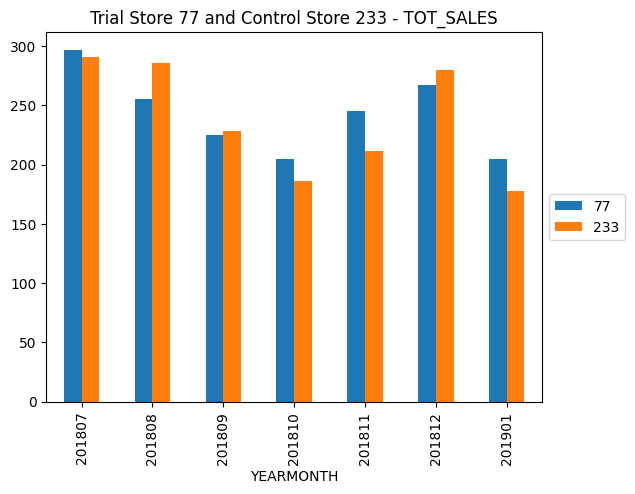

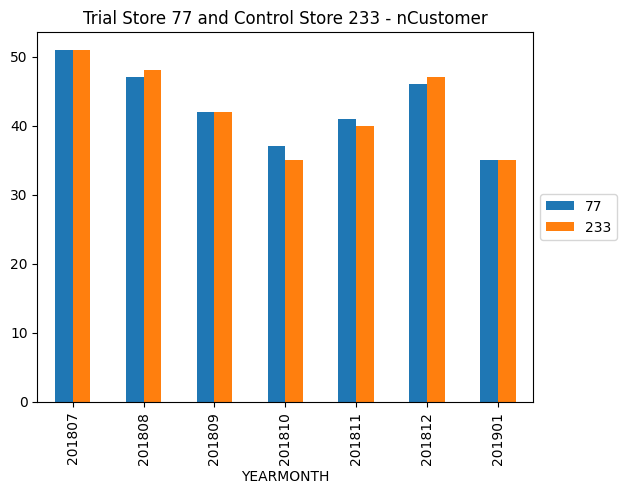

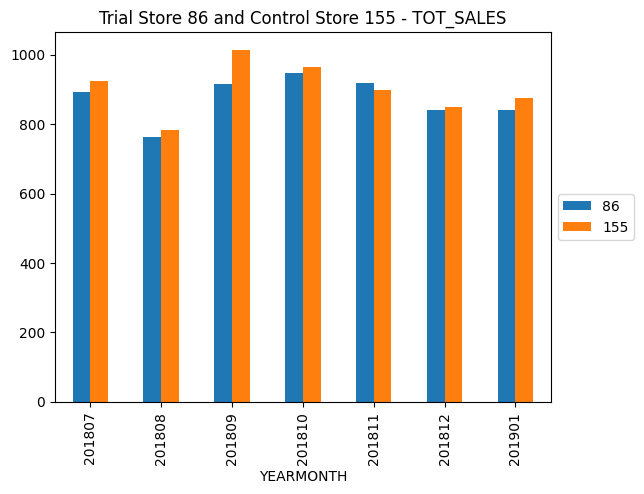

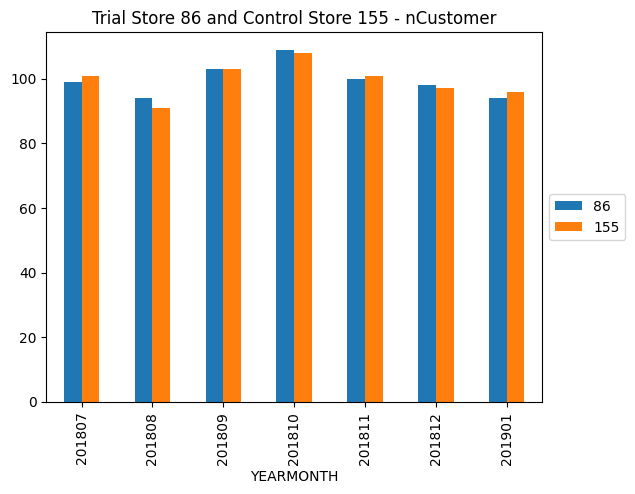

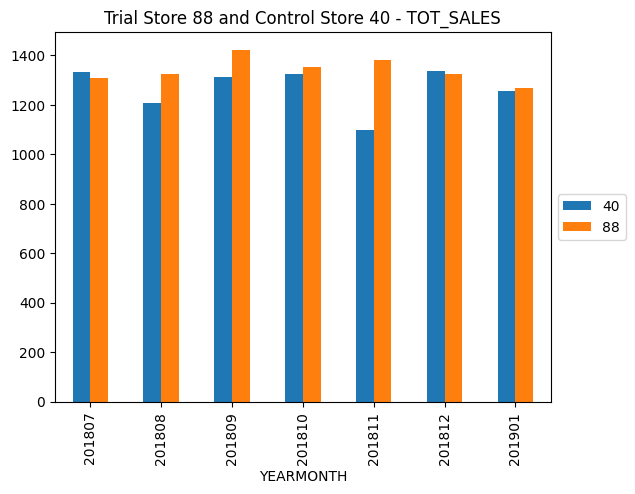

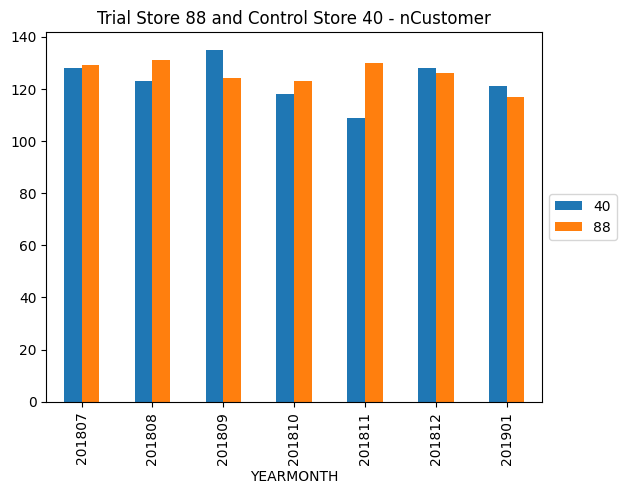

In [48]:
trial_control_dic = {77:233, 86:155, 88:40}
for key, val in trial_control_dic.items():
    pretrial_full_observ[pretrial_full_observ["STORE_NBR"].isin([key, val])].groupby(["YEARMONTH", "STORE_NBR"]).sum()["TOT_SALES"].unstack().plot.bar()
    plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
    plt.title("Trial Store "+str(key)+" and Control Store "+str(val)+" - TOT_SALES")
    plt.show()
    pretrial_full_observ[pretrial_full_observ["STORE_NBR"].isin([key, val])].groupby(
    ["YEARMONTH", "STORE_NBR"]).sum()["nCustomers"].unstack().plot.bar()
    plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
    plt.title("Trial Store "+str(key)+" and Control Store "+str(val)+" - nCustomer")
    plt.show()
    print('\n')


Next, we will compare the performance of the Trial Stores with their corresponding Control Stores during the trial period. To make this comparison fair, we first adjust the Control Stores’ performance so that it aligns with the Trial Stores’ pre-trial performance. We do this by calculating the ratio of the Trial Store’s performance to the Control Store’s performance during the pre-trial period and using it as a scaling factor. Starting with TOT_SALES, we multiply the Control Store’s values by this factor before comparing the results during the trial period

In [49]:
#Ratio of Store 77 and its Control store.
sales_ratio_77 = pretrial_full_observ[pretrial_full_observ["STORE_NBR"] == 77]["TOT_SALES"].sum() /  pretrial_full_observ[pretrial_full_observ["STORE_NBR"] == 233]["TOT_SALES"].sum()

#Ratio of Store 86 and its Control store.
sales_ratio_86 = pretrial_full_observ[pretrial_full_observ["STORE_NBR"] == 86]["TOT_SALES"].sum() /  pretrial_full_observ[pretrial_full_observ["STORE_NBR"] == 155]["TOT_SALES"].sum()

#Ratio of Store 88 and its Control store.
sales_ratio_88 = pretrial_full_observ[pretrial_full_observ["STORE_NBR"] == 88]["TOT_SALES"].sum() /  pretrial_full_observ[pretrial_full_observ["STORE_NBR"] == 40]["TOT_SALES"].sum()


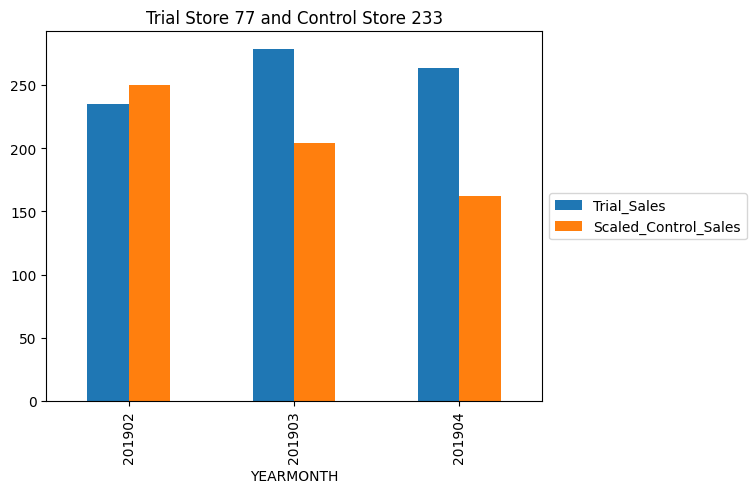

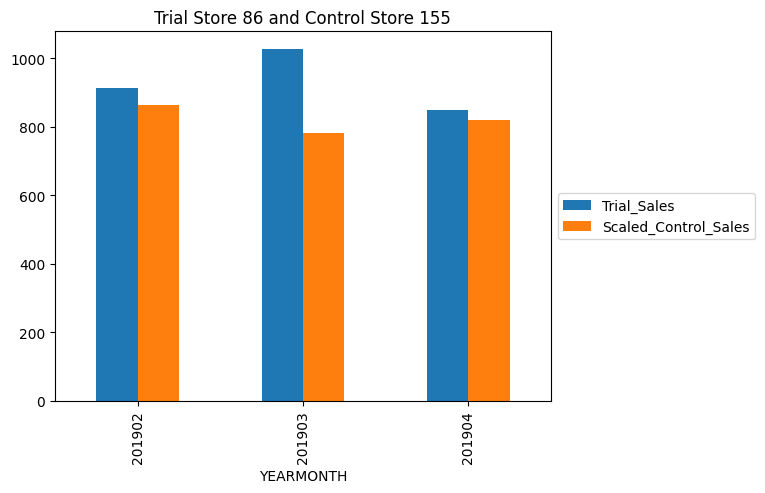

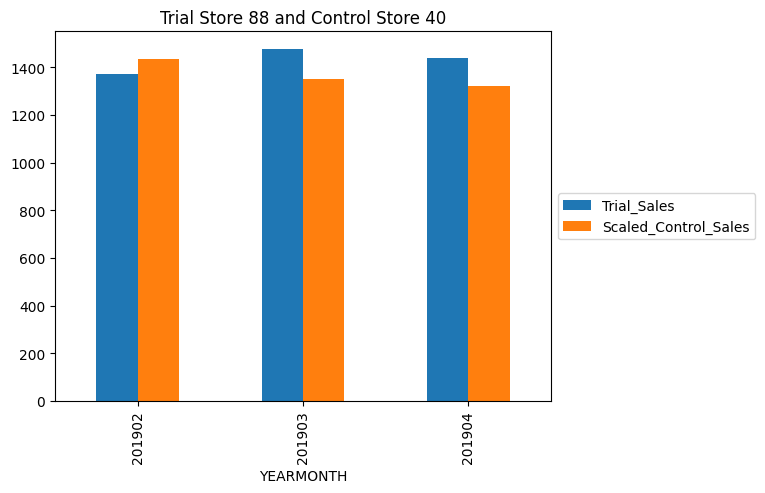

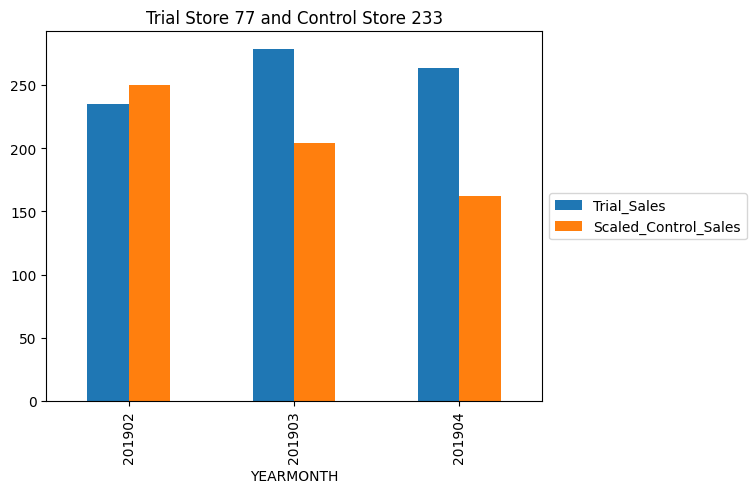

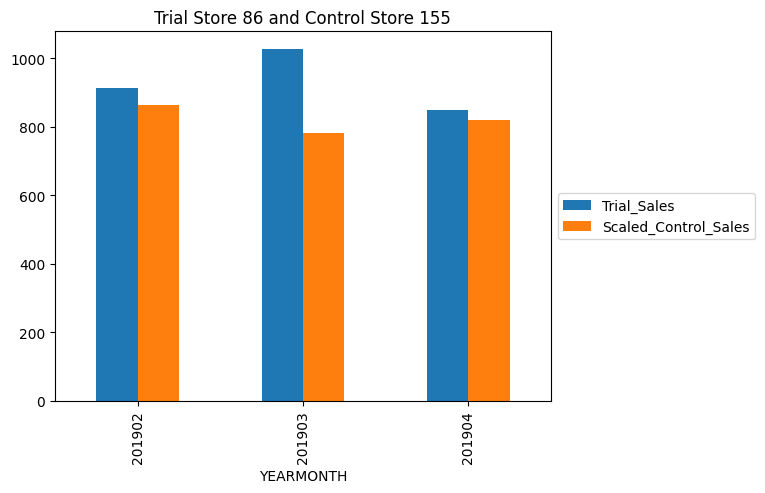

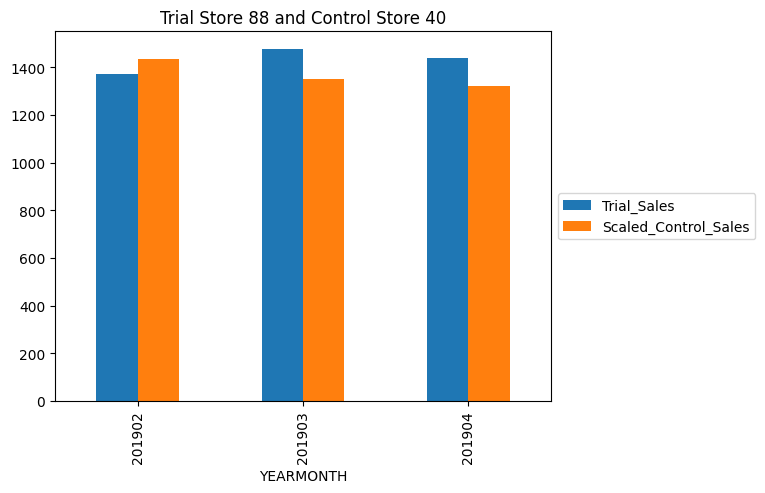

In [ ]:
trial_full_observ = full_observe[(full_observe["YEARMONTH"] >= 201902) & (full_observe["YEARMONTH"] <= 201904)]
scaled_sales_control_stores = full_observe[full_observe["STORE_NBR"].isin([233, 155, 40])][["STORE_NBR", "YEARMONTH", "TOT_SALES"]]

def scaler(row):
    if row["STORE_NBR"] == 233:
        return row["TOT_SALES"] * sales_ratio_77
    elif row["STORE_NBR"] == 155:
        return row["TOT_SALES"] * sales_ratio_86
    elif row["STORE_NBR"] == 40:
        return row["TOT_SALES"] * sales_ratio_88
    
scaled_sales_control_stores["ScaledSales"] = scaled_sales_control_stores.apply(lambda row: scaler(row), axis = 1)

trial_scaled_sales_control_stores  =  scaled_sales_control_stores[(scaled_sales_control_stores["YEARMONTH"] >= 201902) & (scaled_sales_control_stores["YEARMONTH"] <= 201904)]
pretrial_scaled_Sales_control_stores = scaled_sales_control_stores[scaled_sales_control_stores["YEARMONTH"] < 201902]

percentage_diff = {}

for trial, control in trial_control_dic.items():
    a = trial_scaled_sales_control_stores[trial_scaled_sales_control_stores["STORE_NBR"] == control]
    b = trial_full_observ[trial_full_observ["STORE_NBR"] == trial][["STORE_NBR","YEARMONTH", "TOT_SALES"]]
    percentage_diff[trial] = b["TOT_SALES"].sum() / a["ScaledSales"].sum()
    b[["YEARMONTH", "TOT_SALES"]].merge(a[["YEARMONTH", "ScaledSales"]],on="YEARMONTH").set_index("YEARMONTH").rename(columns={"ScaledSales":"Scaled_Control_Sales", "TOT_SALES":"Trial_Sales"}).plot.bar()
    plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
    plt.title("Trial Store "+str(trial)+" and Control Store "+str(control))
    plt.show()

    


In [53]:
percentage_diff

{77: np.float64(1.2615468650086281),
 86: np.float64(1.1315014357363697),
 88: np.float64(1.043458345854219)}

In [ ]:
temp1 = scaled_sales_control_stores.sort_values(by = ["STORE_NBR", "YEARMONTH"], ascending=[False, True]).reset_index().drop(["TOT_SALES", "index"], axis=1) 
temp2 = full_observe[full_observe["STORE_NBR"].isin([77,86,88])][["STORE_NBR", "YEARMONTH", "TOT_SALES"]].reset_index().drop(["index", "YEARMONTH"], axis=1)
scaledsales_vs_trial = pd.concat([temp1, temp2], axis=1)
scaledsales_vs_trial.columns = [
    "c_STORE_NBR",
    "YEARMONTH",
    "c_ScaledSales",
    "t_STORE_NBR",
    "t_TOT_SALES"
]
scaledsales_vs_trial["sales_percentage_Diff"] = (scaledsales_vs_trial["t_TOT_SALES"] - scaledsales_vs_trial["c_ScaledSales"]) /  (((scaledsales_vs_trial["t_TOT_SALES"] + scaledsales_vs_trial["c_ScaledSales"])/2))
def label_period(cell):
    if cell < 201902:
        return "Pre-Trial"
    elif cell > 201904:
        return "Post Trial"
    else:
        return "Trial"
scaledsales_vs_trial["trial_period"] = scaledsales_vs_trial["YEARMONTH"].apply(lambda cell: label_period(cell))
scaledsales_vs_trial[scaledsales_vs_trial["trial_period"] == "Trial"]



,c_STORE_NBR,YEARMONTH,c_ScaledSales,t_STORE_NBR,t_TOT_SALES,sales_percentage_Diff,trial_period
7,233,201902,249.762622,77,235.0,-0.060907,Trial
8,233,201903,203.802205,77,278.5,0.309755,Trial
9,233,201904,162.345704,77,263.5,0.475075,Trial
19,155,201902,864.522060,86,913.2,0.054764,Trial
20,155,201903,780.320405,86,1026.8,0.272787,Trial
21,155,201904,819.317024,86,848.2,0.034642,Trial
31,40,201902,1434.399269,88,1370.2,-0.045781,Trial
32,40,201903,1352.064709,88,1477.2,0.088458,Trial
33,40,201904,1321.797762,88,1439.4,0.085182,Trial


Step 1:
Check the null hypothesis of 0 difference between the Control Store’s Pre-Trial and Trial period performance.

Step 2:
Prove that Control and Trial stores are statistically similar.

Check the p-value between Control Store’s Pre-Trial and Trial Store’s Pre-Trial:

If p-value < 5% → stores are significantly different
If p-value > 5% → stores are not significantly different (similar)

Step 3:
After confirming the null hypothesis in Steps 1 and 2, check whether the Percentage Difference between Trial and Control stores during the trial period is different from the pre-trial period.

Calculate the T-value for each trial month (Feb, Mar, Apr 2019):

Mean = average Percentage Difference during pre-trial
Standard deviation = stdev of Percentage Difference during pre-trial

In [58]:
from scipy.stats import ttest_ind, t
for num in [40,155,233]:
    print("Store", num)
    print(ttest_ind(
    pretrial_scaled_Sales_control_stores[pretrial_scaled_Sales_control_stores["STORE_NBR"] == num]["ScaledSales"],
    trial_scaled_sales_control_stores[trial_scaled_sales_control_stores["STORE_NBR"] == num]["ScaledSales"],
    equal_var = False
    ), '\n')

alpha = 0.05
print("Critical t-value for 95% confidence interval:")
print(t.ppf((alpha/2, 1-alpha/2),  df=min([len(pretrial_scaled_Sales_control_stores[pretrial_scaled_Sales_control_stores["STORE_NBR"] == num]),
                       len(trial_scaled_sales_control_stores[trial_scaled_sales_control_stores["STORE_NBR"] == num])])-1))
     


  



Store 40
TtestResult(statistic=np.float64(-0.5958372343168558), pvalue=np.float64(0.5722861621434026), df=np.float64(6.228548324256264)) 

Store 155
TtestResult(statistic=np.float64(1.4291956879290917), pvalue=np.float64(0.19727058651603432), df=np.float64(6.794437403919926)) 

Store 233
TtestResult(statistic=np.float64(1.191102601097452), pvalue=np.float64(0.2944500606486209), df=np.float64(4.355475642590669)) 

Critical t-value for 95% confidence interval:
[-4.30265273  4.30265273]


In [62]:
a = pretrial_scaled_Sales_control_stores[pretrial_scaled_Sales_control_stores["STORE_NBR"] == 40]["ScaledSales"]
b = trial_scaled_sales_control_stores[trial_scaled_sales_control_stores["STORE_NBR"] == 40]["ScaledSales"]

In [63]:
for trial, cont in trial_control_dic.items():
    print("Trial store:", trial, ", Control store:", cont)
    print(ttest_ind(
        pretrial_full_observ[pretrial_full_observ["STORE_NBR"] == trial]["TOT_SALES"],
        pretrial_scaled_Sales_control_stores[pretrial_scaled_Sales_control_stores["STORE_NBR"] == cont]["ScaledSales"],
        equal_var=True), '\n')
    
alpha = 0.05
print("Critical t-value for 95% confidence interval:")
print(t.ppf((alpha/2, 1-alpha/2), df=len(pretrial_full_observ[pretrial_full_observ["STORE_NBR"] == trial])-1))
    

Trial store: 77 , Control store: 233
TtestResult(statistic=np.float64(-1.2533353315065932e-15), pvalue=np.float64(0.999999999999999), df=np.float64(12.0)) 

Trial store: 86 , Control store: 155
TtestResult(statistic=np.float64(3.1048311203382156e-15), pvalue=np.float64(0.9999999999999976), df=np.float64(12.0)) 

Trial store: 88 , Control store: 40
TtestResult(statistic=np.float64(-5.69358613974361e-15), pvalue=np.float64(0.9999999999999956), df=np.float64(12.0)) 

Critical t-value for 95% confidence interval:
[-2.44691185  2.44691185]


In [69]:
print(scaledsales_vs_trial["trial_period"].value_counts())

trial_period
Pre-Trial     21
Trial          9
Post Trial     6
Name: count, dtype: int64


In [70]:
for trial, cont in trial_control_dic.items():
    print("Trial store:", trial, ", Control store:", cont)
    temp_pre = scaledsales_vs_trial[(scaledsales_vs_trial["c_STORE_NBR"] == cont) & (scaledsales_vs_trial["trial_period"] == "Pre-Trial")]
    std = temp_pre["sales_percentage_Diff"].std()
    mean = temp_pre["sales_percentage_Diff"].mean()
    for t_month in scaledsales_vs_trial[scaledsales_vs_trial["trial_period"] == "Trial"]["YEARMONTH"].unique():
        pdif = scaledsales_vs_trial[(scaledsales_vs_trial["YEARMONTH"] == t_month) & (scaledsales_vs_trial["t_STORE_NBR"] == trial)]["sales_percentage_Diff"]
        print(t_month,":",(float(pdif)-mean)/std)
    print('\n')
print("Critical t-value for 95% confidence interval:")
conf_intv_95 = t.ppf(0.95, df = len(temp_pre)-1)
print(conf_intv_95)


Trial store: 77 , Control store: 233
201902 : -0.7171038288055838
201903 : 3.035317928855674
201904 : 4.708944418758219


Trial store: 86 , Control store: 155
201902 : 1.4133618775921597
201903 : 7.123063846042147
201904 : 0.8863824572944234


Trial store: 88 , Control store: 40
201902 : -0.5481633746817577
201903 : 1.0089992743637823
201904 : 0.9710006270463672


Critical t-value for 95% confidence interval:
1.9431802805153042


C:\Users\karan\AppData\Local\Temp\ipykernel_14704\3621467743.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(t_month,":",(float(pdif)-mean)/std)


In [78]:
print(scaledsales_vs_trial[["c_STORE_NBR", "t_STORE_NBR"]].head(10))

   c_STORE_NBR  t_STORE_NBR
0          233           77
1          233           77
2          233           77
3          233           77
4          233           77
5          233           77
6          233           77
7          233           77
8          233           77
9          233           77


Expected Control: 233
Actual Control in data: [233]


<Figure size 640x480 with 0 Axes>

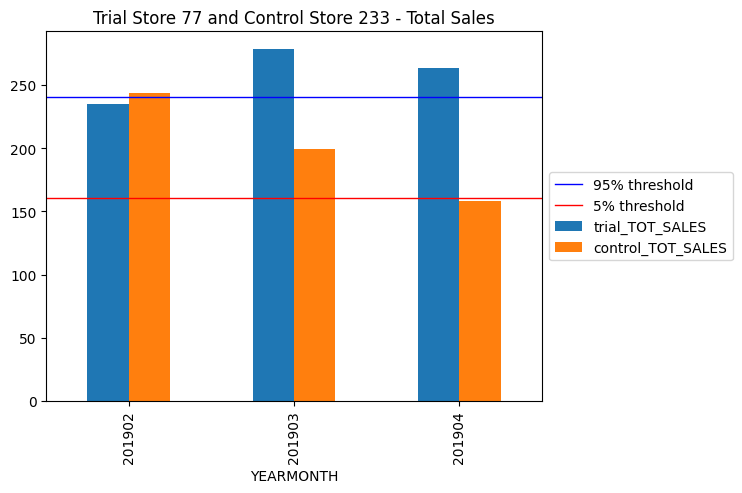

Expected Control: 155
Actual Control in data: [155]


<Figure size 640x480 with 0 Axes>

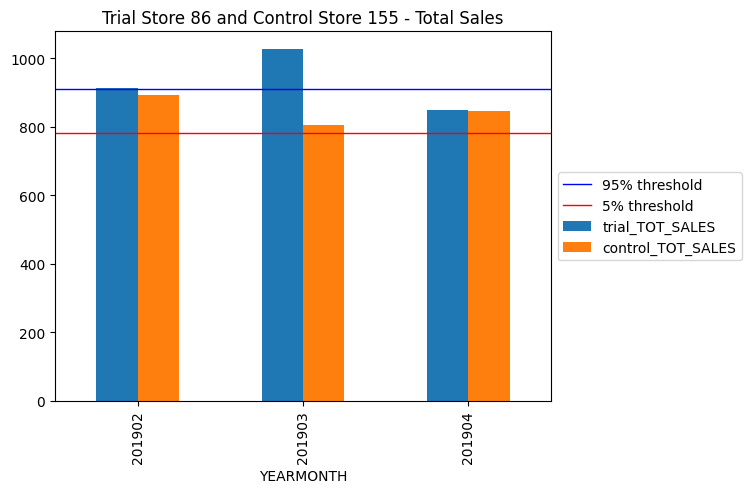

Expected Control: 40
Actual Control in data: [40]


<Figure size 640x480 with 0 Axes>

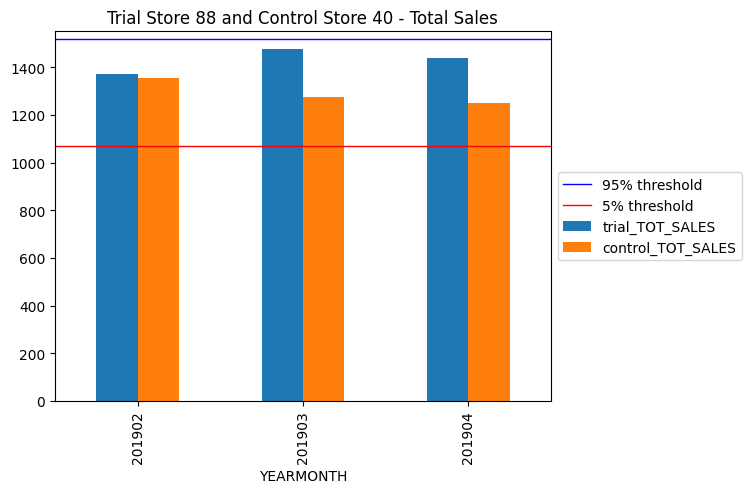

In [80]:
for trial, control in trial_control_dic.items():
    plt.figure()  
    a = trial_scaled_sales_control_stores[trial_scaled_sales_control_stores["STORE_NBR"] == control].rename(columns = {"TOT_SALES":"control_TOT_SALES"})
    b = trial_full_observ[trial_full_observ["STORE_NBR"] == trial][["STORE_NBR","YEARMONTH", "TOT_SALES"]].rename(columns = {"TOT_SALES":"trial_TOT_SALES"})
    comb = b[["YEARMONTH", "trial_TOT_SALES"]].merge(a[["YEARMONTH", "control_TOT_SALES"]], on = "YEARMONTH").set_index("YEARMONTH")
    comb.plot.bar()
    cont_sc_sales = trial_scaled_sales_control_stores[trial_scaled_sales_control_stores["STORE_NBR"] == control]["TOT_SALES"]
    std = scaledsales_vs_trial[(scaledsales_vs_trial["c_STORE_NBR"] == control) & (scaledsales_vs_trial["trial_period"] == "Pre-Trial")]["sales_percentage_Diff"].std()
    thresh95 = cont_sc_sales.mean() + (cont_sc_sales.mean() * std * 2)
    thresh5 = cont_sc_sales.mean() - (cont_sc_sales.mean() * std * 2) 
    print("Expected Control:", control)
    print("Actual Control in data:", a["STORE_NBR"].unique()) 
    plt.axhline(y=thresh95,linewidth=1, color='b', label="95% threshold")
    plt.axhline(y=thresh5,linewidth=1, color='r', label="5% threshold")
    plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
    plt.title("Trial Store "+str(trial)+" and Control Store "+str(control)+" - Total Sales")
    plt.savefig("TS {} and CS {} - TOT_SALES.png".format(trial,control), bbox_inches="tight")
    plt.show()     

In [81]:
ncust_ratio_77 = pretrial_full_observ[pretrial_full_observ["STORE_NBR"] == 77]["nCustomers"].sum() /  pretrial_full_observ[pretrial_full_observ["STORE_NBR"] == 233]["nCustomers"].sum()

ncust_ratio_86 = pretrial_full_observ[pretrial_full_observ["STORE_NBR"] == 86]["nCustomers"].sum() /  pretrial_full_observ[pretrial_full_observ["STORE_NBR"] == 155]["nCustomers"].sum()

ncust_ratio_88 = pretrial_full_observ[pretrial_full_observ["STORE_NBR"] == 88]["nCustomers"].sum() /  pretrial_full_observ[pretrial_full_observ["STORE_NBR"] == 40]["nCustomers"].sum()

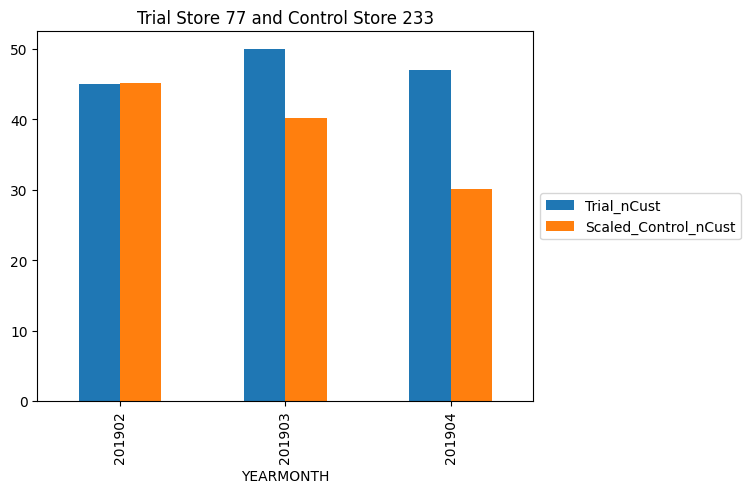

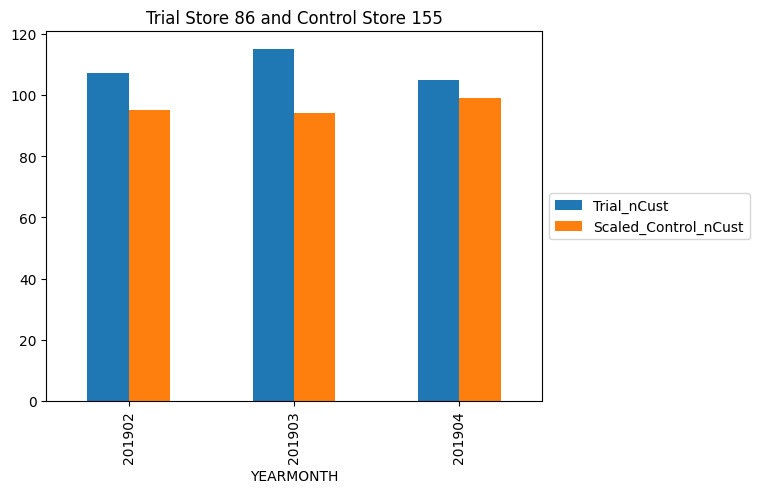

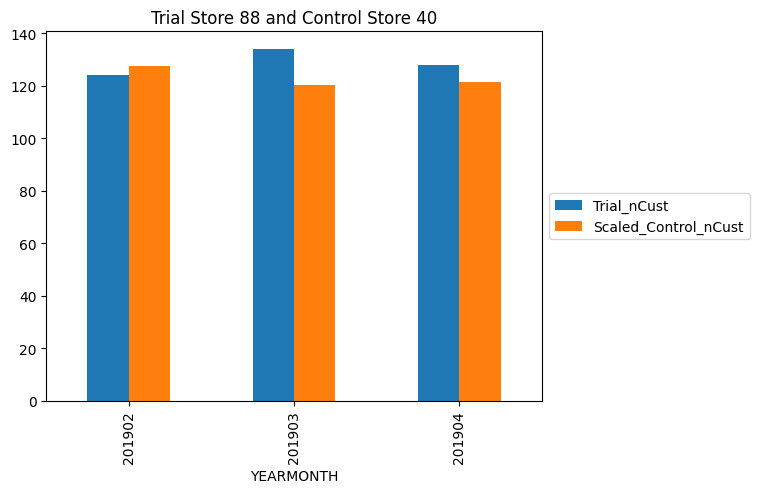

In [107]:
scaled_ncust_control_stores = full_observe[
    full_observe["STORE_NBR"].isin([233, 155, 40])
][["STORE_NBR", "YEARMONTH", "nCustomers"]]

# Vectorized scaling
scaled_ncust_control_stores["ScaledNcust"] = (
    scaled_ncust_control_stores["nCustomers"] *
    scaled_ncust_control_stores["STORE_NBR"].map({
        233: ncust_ratio_77,
        155: ncust_ratio_86,
        40: ncust_ratio_88
    })
)

# Split data
trial_scaled_ncust_control_stores = scaled_ncust_control_stores[
    (scaled_ncust_control_stores["YEARMONTH"] >= 201902) &
    (scaled_ncust_control_stores["YEARMONTH"] <= 201904)
]
pretrial_scaled_ncust_control_stores = scaled_ncust_control_stores[scaled_ncust_control_stores["YEARMONTH"] < 201902]

ncust_percentage_diff = {}

for trial, control in trial_control_dic.items():
    
    a = trial_scaled_ncust_control_stores[
        trial_scaled_ncust_control_stores["STORE_NBR"] == control
    ]
    
    b = trial_full_observ[
        trial_full_observ["STORE_NBR"] == trial
    ][["YEARMONTH", "nCustomers"]]

    control_sum = a["ScaledNcust"].sum()
    trial_sum = b["nCustomers"].sum()

    ncust_percentage_diff[trial] = trial_sum / control_sum if control_sum != 0 else 0

    (
        b.merge(a[["YEARMONTH", "ScaledNcust"]], on="YEARMONTH")
         .set_index("YEARMONTH")
         .rename(columns={
             "ScaledNcust": "Scaled_Control_nCust",
             "nCustomers": "Trial_nCust"
         })
         .plot.bar()
    )

    plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
    plt.title(f"Trial Store {trial} and Control Store {control}")
    plt.show()

In [86]:
ncust_percentage_diff

{77: np.float64(1.2306529009742622),
 86: np.float64(1.1354166666666667),
 88: np.float64(1.0444876946258161)}

In [87]:
temp1 = scaled_ncust_control_stores.sort_values(by = ["STORE_NBR", "YEARMONTH"], ascending=[False, True]).reset_index().drop(["nCustomers", "index"], axis=1)
temp2 = full_observe[full_observe["STORE_NBR"].isin([77,86,88])][["STORE_NBR", "YEARMONTH", "nCustomers"]].reset_index().drop(["index", "YEARMONTH"], axis=1)
scaledncust_vs_trial = pd.concat([temp1, temp2], axis=1)
scaledncust_vs_trial.columns = [
    "c_STORE_NBR", "YEARMONTH", "c_ScaledNcust",
    "t_STORE_NBR", "t_nCustomers"
]
scaledncust_vs_trial["ncust_percentage_diff"] = ((scaledncust_vs_trial["t_nCustomers"] - scaledncust_vs_trial["c_ScaledNcust"]) / ((scaledncust_vs_trial["t_nCustomers"] + scaledncust_vs_trial["c_ScaledNcust"])/2))

scaledncust_vs_trial["trial_period"] = scaledncust_vs_trial["YEARMONTH"].apply(lambda cell: label_period(cell))
scaledncust_vs_trial[scaledncust_vs_trial["trial_period"] == "Trial"]


,c_STORE_NBR,YEARMONTH,c_ScaledNcust,t_STORE_NBR,t_nCustomers,ncust_percentage_diff,trial_period
7,233,201902,45.151007,77,45,-0.003350,Trial
8,233,201903,40.134228,77,50,0.218913,Trial
9,233,201904,30.100671,77,47,0.438370,Trial
19,155,201902,95.000000,86,107,0.118812,Trial
20,155,201903,94.000000,86,115,0.200957,Trial
21,155,201904,99.000000,86,105,0.058824,Trial
31,40,201902,127.610209,88,124,-0.028697,Trial
32,40,201903,120.464037,88,134,0.106388,Trial
33,40,201904,121.484919,88,128,0.052228,Trial


In [93]:
print(pretrial_scaled_Sales_control_stores.columns)

Index(['STORE_NBR', 'YEARMONTH', 'TOT_SALES', 'ScaledSales'], dtype='object')


Check significance of Trial minus Control stores nCustomers Percentage Difference Pre-Trial vs Trial.

Step 1: Check null hypothesis of 0 difference between control store's Pre-Trial and Trial period performance.

Step 2: Proof control and trial stores are similar statistically

Step 3: After checking Null Hypothesis of first 2 step to be true, we can check Null Hypothesis of Percentage Difference between Trial and Control stores during pre-trial is the same as during trial.

In [111]:
for num in [40, 155, 233]:
    print("Store", num)
    print(ttest_ind(
        pretrial_scaled_ncust_control_stores[pretrial_scaled_ncust_control_stores["STORE_NBR"] == num]["ScaledNcust"],

        trial_scaled_ncust_control_stores[trial_scaled_ncust_control_stores["STORE_NBR"] == num]["ScaledNcust"],

        equal_var = False
    ), '\n')
    
    
alpha = 0.05
print("Critical t-value for 95% confidence interval:")
print(t.ppf((alpha/2, 1-alpha/2), df=min([len(pretrial_scaled_ncust_control_stores[pretrial_scaled_ncust_control_stores["STORE_NBR"] == num]),
                       len(trial_scaled_ncust_control_stores[trial_scaled_ncust_control_stores["STORE_NBR"] == num])])-1))

    

Store 40
TtestResult(statistic=np.float64(0.644732693420032), pvalue=np.float64(0.5376573016017125), df=np.float64(7.7735551763644395)) 

Store 155
TtestResult(statistic=np.float64(1.3888888888888882), pvalue=np.float64(0.20434598632788586), df=np.float64(7.572528547077964)) 

Store 233
TtestResult(statistic=np.float64(0.8442563765225701), pvalue=np.float64(0.4559280037660258), df=np.float64(3.2638055826510652)) 

Critical t-value for 95% confidence interval:
[-4.30265273  4.30265273]


In [110]:
"ScaledNcust" in pretrial_scaled_Sales_control_stores.columns

False

In [120]:
for trial, cont in trial_control_dic.items():
    print("Trial store:", trial, ", Control store:", cont)
    print(ttest_ind(pretrial_full_observ[pretrial_full_observ["STORE_NBR"] == trial]["nCustomers"],
                   pretrial_scaled_ncust_control_stores[pretrial_scaled_ncust_control_stores["STORE_NBR"] == cont]["ScaledNcust"],
                    equal_var=True), '\n')
    
    alpha = 0.05
    print("Critical t-value for 95% confidence interval:")
    print(t.ppf((alpha/2, 1-alpha/2), df=len(pretrial_full_observ[pretrial_full_observ["STORE_NBR"] == trial])-1))

    



Trial store: 77 , Control store: 233
TtestResult(statistic=np.float64(0.0), pvalue=np.float64(1.0), df=np.float64(12.0)) 

Critical t-value for 95% confidence interval:
[-2.44691185  2.44691185]
Trial store: 86 , Control store: 155
TtestResult(statistic=np.float64(0.0), pvalue=np.float64(1.0), df=np.float64(12.0)) 

Critical t-value for 95% confidence interval:
[-2.44691185  2.44691185]
Trial store: 88 , Control store: 40
TtestResult(statistic=np.float64(-7.648483953264653e-15), pvalue=np.float64(0.999999999999994), df=np.float64(12.0)) 

Critical t-value for 95% confidence interval:
[-2.44691185  2.44691185]


In [ ]:
for trial, cont in trial_control_dic.items():
    print("Trial store:", trial, ", Control store:", cont)
    temp_pre = scaledncust_vs_trial[(scaledncust_vs_trial["c_STORE_NBR"] == cont) & (scaledncust_vs_trial["trial_period"]=="Pre-Trial")]
    std = temp_pre["ncust_percentage_diff"].std()
    mean = temp_pre["ncust_percentage_diff"].mean()
   
    for t_month in scaledncust_vs_trial[scaledncust_vs_trial["trial_period"] == "Trial"]["YEARMONTH"].unique():
        pdif = scaledncust_vs_trial[(scaledncust_vs_trial["YEARMONTH"] == t_month) & (scaledncust_vs_trial["t_STORE_NBR"] == trial)]["ncust_percentage_diff"]
        print(t_month,":",(float(pdif)-mean)/std)
    print('\n')
    
print("Critical t-value for 95% confidence interval:")
conf_intv_95 = t.ppf(0.95, df=len(temp_pre)-1)
print(conf_intv_95)

Trial store: 77 , Control store: 233
201902 : -0.19886295797440687
201903 : 8.009609025380932
201904 : 16.114474772873923


Trial store: 86 , Control store: 155
201902 : 6.220524882227514
201903 : 10.52599074274189
201904 : 3.0763575852842706


Trial store: 88 , Control store: 40
201902 : -0.3592881735131531
201903 : 1.2575196020616801
201904 : 0.6092905590514273


Critical t-value for 95% confidence interval:
1.9431802805153042


C:\Users\karan\AppData\Local\Temp\ipykernel_14704\1749047123.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(t_month,":",(float(pdif)-mean)/std)


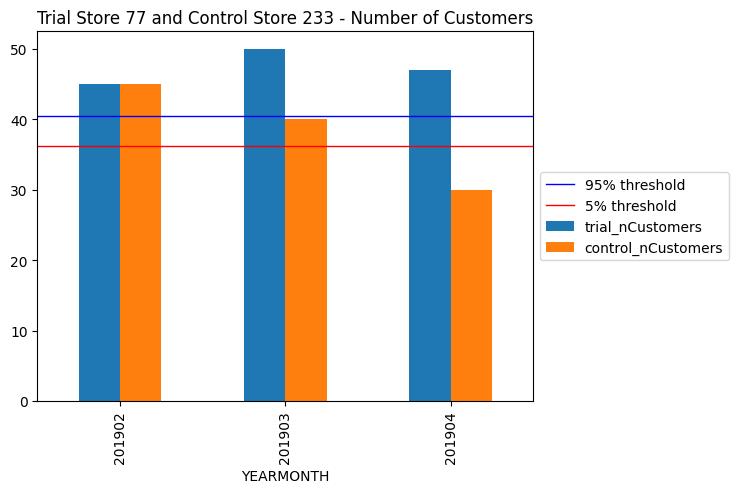

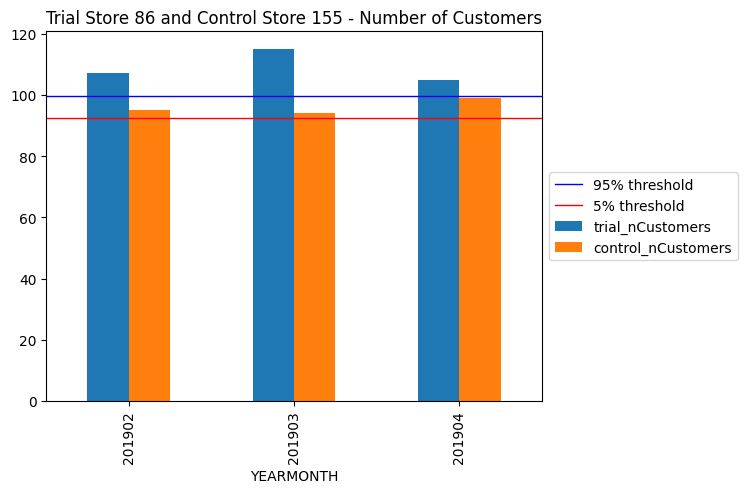

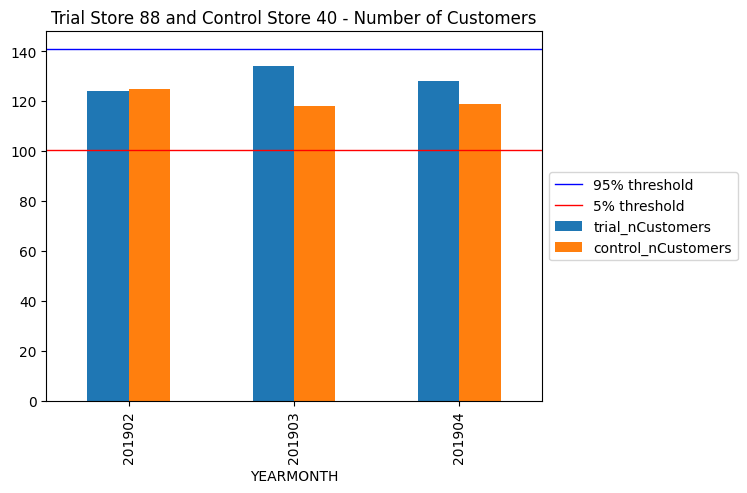

In [128]:
for trial , control in trial_control_dic.items():
    a = trial_scaled_ncust_control_stores[trial_scaled_ncust_control_stores["STORE_NBR"] == control].rename(columns={"nCustomers": "control_nCustomers"})
    b = trial_full_observ[trial_full_observ["STORE_NBR"] == trial][["STORE_NBR", "YEARMONTH", "nCustomers"]].rename(columns={"nCustomers": "trial_nCustomers"})
    comb = b[["YEARMONTH", "trial_nCustomers"]].merge(a[["YEARMONTH", "control_nCustomers"]], on="YEARMONTH").set_index("YEARMONTH")
    comb.plot.bar()
    cont_sc_ncust = trial_scaled_ncust_control_stores[trial_scaled_ncust_control_stores["STORE_NBR"] == control]["nCustomers"]
    std = scaledncust_vs_trial[(scaledncust_vs_trial["c_STORE_NBR"] == control) & (scaledncust_vs_trial["trial_period"] == "Pre-Trial")]["ncust_percentage_diff"].std()
    thresh95 = cont_sc_ncust.mean() + (cont_sc_ncust.mean() * std * 2)
    thresh5  = cont_sc_ncust.mean() - (cont_sc_ncust.mean() * std * 2)  
    plt.axhline(y=thresh95,linewidth=1, color='b', label="95% threshold")
    plt.axhline(y=thresh5,linewidth=1, color='r', label="5% threshold")
    plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
    plt.title("Trial Store "+str(trial)+" and Control Store "+str(control)+" - Number of Customers")
    plt.savefig("TS {} and CS {} - nCustomers.png".format(trial,control), bbox_inches="tight")
    plt.show()      


We can see that Trial store 77 sales for Feb, March, and April exceeds 95% threshold of control store. Same goes to store 86 sales for all 3 trial months.

1. Trial store 77: Control store 233
2. Trial store 86: Control store 155
3. Trial store 88: Control store 40
4. Both trial store 77 and 86 showed significant increase in Total Sales and Number of Customers during trial period. But not for trial store 88. Perhaps the client knows if there's anything about trial 88 that differs it from the other two trial.
5. Overall the trial showed positive significant result.